# IPC and Rainfall Relationship Analysis

This notebook analyzes the relationship between rainfall conditions and IPC food insecurity severity in Kenya's target counties.

The dataset used here combines:
- IPC food insecurity outcomes
- county-level CHIRPS rainfall features
- 3-month and 6-month rainfall summaries before each IPC analysis period

Main questions:
1. Do counties with lower rainfall show higher IPC severity?
2. Is 3-month or 6-month rainfall more useful for explaining food insecurity?
3. Which counties show repeated high food insecurity despite rainfall variation?
4. Which periods had both low rainfall and high food insecurity?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
MODEL_PATH = Path("../02_data/processed/ipc_rainfall_modeling_dataset.csv")

df = pd.read_csv(MODEL_PATH)

print("Rows and columns:", df.shape)
df.head()

Rows and columns: (322, 13)


,ipc_date,analysis_period,county,max_ipc_phase,phase_3_plus_population,total_population,phase_3_plus_percentage,rainfall_date,mean_rainfall_mm,rainfall_3_month_total,rainfall_6_month_total,rainfall_3_month_avg,rainfall_6_month_avg
0,2019-07-01,Jul 2019,Baringo,4,105555,703697,0.15,2019-06-01,72.692665,143.441454,172.723779,47.813818,28.787296
1,2019-07-01,Jul 2019,Embu,3,32883,219220,0.15,2019-06-01,8.068131,123.946965,156.388124,41.315655,26.064687
2,2019-07-01,Jul 2019,Garissa,4,151183,431950,0.35,2019-06-01,5.417682,55.185197,66.812339,18.395066,11.135390
3,2019-07-01,Jul 2019,Isiolo,4,54413,155465,0.35,2019-06-01,0.936229,26.591658,40.062429,8.863886,6.677072
4,2019-07-01,Jul 2019,Kajiado,3,43536,870721,0.05,2019-06-01,6.391582,62.716861,88.344720,20.905620,14.724120


In [3]:
df["ipc_date"] = pd.to_datetime(df["ipc_date"])
df["rainfall_date"] = pd.to_datetime(df["rainfall_date"])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   ipc_date                 322 non-null    datetime64[us]
 1   analysis_period          322 non-null    str           
 2   county                   322 non-null    str           
 3   max_ipc_phase            322 non-null    int64         
 4   phase_3_plus_population  322 non-null    int64         
 5   total_population         322 non-null    int64         
 6   phase_3_plus_percentage  322 non-null    float64       
 7   rainfall_date            322 non-null    datetime64[us]
 8   mean_rainfall_mm         322 non-null    float64       
 9   rainfall_3_month_total   322 non-null    float64       
 10  rainfall_6_month_total   322 non-null    float64       
 11  rainfall_3_month_avg     322 non-null    float64       
 12  rainfall_6_month_avg     322 non-null    float6

## Question 1: What Is the Relationship Between 6-Month Rainfall and IPC Severity?

This section compares 6-month rainfall totals with IPC food insecurity severity.

The idea is simple: if rainfall is low over several months, food production and livestock conditions may worsen, which can increase food insecurity risk.

In [4]:
df.groupby("max_ipc_phase")[
    [
        "rainfall_3_month_total",
        "rainfall_6_month_total",
        "phase_3_plus_percentage"
    ]
].mean().round(2)

,rainfall_3_month_total,rainfall_6_month_total,phase_3_plus_percentage
max_ipc_phase,,,
2,164.73,319.43,0.00
3,133.66,201.06,0.10
4,78.14,115.83,0.28


### Interpretation

The grouped summary shows a clear pattern between rainfall and IPC food insecurity severity. Counties classified in lower IPC severity levels had higher rainfall totals, while counties classified in higher severity levels had lower rainfall totals.

For IPC Phase 2 records, the average 6-month rainfall total was about 319.43 mm. This dropped to 201.06 mm for IPC Phase 3 and further to 115.83 mm for IPC Phase 4.

At the same time, the average share of people in IPC Phase 3 or worse increased from 0% in Phase 2 records to 10% in Phase 3 records and 28% in Phase 4 records.

This suggests that lower rainfall over the previous months is associated with higher food insecurity severity. The 6-month rainfall total appears especially useful because it captures seasonal rainfall conditions before the IPC analysis period.

In [5]:
phase_summary = (
    df.groupby("max_ipc_phase")[
        [
            "rainfall_3_month_total",
            "rainfall_6_month_total",
            "phase_3_plus_percentage"
        ]
    ]
    .mean()
    .reset_index()
)

phase_summary

,max_ipc_phase,rainfall_3_month_total,rainfall_6_month_total,phase_3_plus_percentage
0,2,164.726817,319.428717,0.000000
1,3,133.663578,201.055021,0.097554
2,4,78.137340,115.826239,0.284076


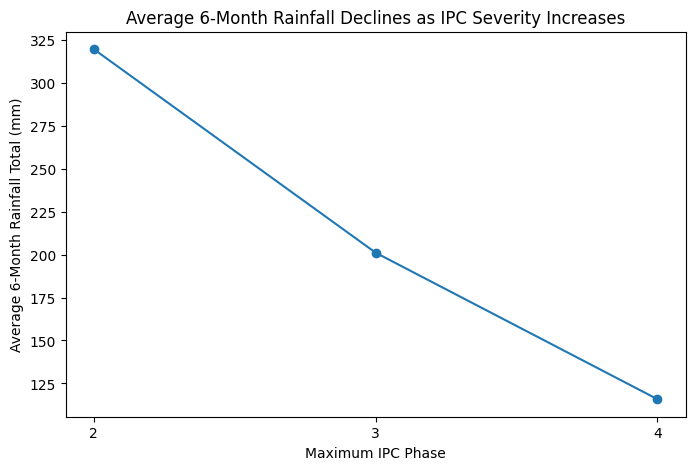

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(
    phase_summary["max_ipc_phase"],
    phase_summary["rainfall_6_month_total"],
    marker="o"
)

plt.xlabel("Maximum IPC Phase")
plt.ylabel("Average 6-Month Rainfall Total (mm)")
plt.title("Average 6-Month Rainfall Declines as IPC Severity Increases")
plt.xticks(phase_summary["max_ipc_phase"])
plt.show()

### Chart Interpretation

The chart shows a clear downward pattern between 6-month rainfall totals and IPC food insecurity severity.

Counties classified as IPC Phase 2 had the highest average 6-month rainfall total, while counties classified as IPC Phase 4 had the lowest average 6-month rainfall total.

This suggests that lower rainfall over the previous six months is associated with higher food insecurity severity. The result supports the use of rainfall as an early warning indicator in the project.

## Question 2: Does Lower Rainfall Relate to a Higher Share of People in Crisis or Worse?

This section compares 6-month rainfall totals with the percentage of people in IPC Phase 3 or worse.

Instead of grouping by IPC phase, this analysis checks the relationship at county-period level.

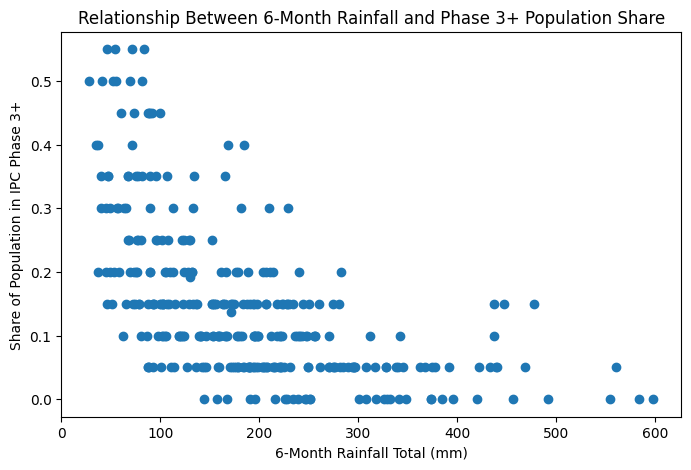

In [7]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df["rainfall_6_month_total"],
    df["phase_3_plus_percentage"]
)

plt.xlabel("6-Month Rainfall Total (mm)")
plt.ylabel("Share of Population in IPC Phase 3+")
plt.title("Relationship Between 6-Month Rainfall and Phase 3+ Population Share")
plt.show()

### Interpretation

The scatter plot shows a negative relationship between 6-month rainfall totals and the share of the population in IPC Phase 3 or worse.

County-periods with low 6-month rainfall often had higher Phase 3+ population shares. Many of the highest food insecurity observations appear when rainfall totals are below about 100 mm.

When 6-month rainfall totals are higher, especially above 300–400 mm, the Phase 3+ population share is usually much lower.

This suggests that rainfall deficits may be an important early warning signal for food insecurity severity. However, rainfall alone does not explain every case, so later analysis should also consider other drivers such as food prices, conflict, livelihoods, and market access.

In [8]:
correlation = df["rainfall_6_month_total"].corr(df["phase_3_plus_percentage"])

print("Correlation between 6-month rainfall and Phase 3+ percentage:", round(correlation, 3))

Correlation between 6-month rainfall and Phase 3+ percentage: -0.585


### Correlation Interpretation

The correlation between 6-month rainfall total and Phase 3+ population share is -0.585.

This shows a moderate negative relationship. In simple terms, county-periods with lower rainfall over the previous six months tended to have a higher share of people in IPC Phase 3 or worse.

This supports the idea that rainfall is a useful early warning indicator for food insecurity risk. However, the relationship is not perfect, which means rainfall alone cannot explain all food insecurity outcomes. Other factors such as food prices, conflict, livelihoods, and market access may also play important roles.

## Question 3: Is 3-Month or 6-Month Rainfall More Related to Food Insecurity?

This section compares the correlation between Phase 3+ population share and different rainfall features.

The goal is to understand whether short-term rainfall conditions or longer seasonal rainfall conditions are more strongly linked with food insecurity severity.

In [9]:
rainfall_correlation = df[
    [
        "mean_rainfall_mm",
        "rainfall_3_month_total",
        "rainfall_6_month_total",
        "rainfall_3_month_avg",
        "rainfall_6_month_avg",
        "phase_3_plus_percentage"
    ]
].corr()["phase_3_plus_percentage"].sort_values()

rainfall_correlation

rainfall_6_month_avg      -0.585207
rainfall_6_month_total    -0.585207
rainfall_3_month_total    -0.470460
rainfall_3_month_avg      -0.470460
mean_rainfall_mm          -0.315652
phase_3_plus_percentage    1.000000
Name: phase_3_plus_percentage, dtype: float64

### Interpretation

The correlation results show that 6-month rainfall features have the strongest relationship with the share of the population in IPC Phase 3 or worse.

Both `rainfall_6_month_total` and `rainfall_6_month_avg` have a correlation of about -0.585 with `phase_3_plus_percentage`. This means that lower rainfall over the previous six months is moderately associated with a higher share of people in Crisis level or worse.

The 3-month rainfall features also show a negative relationship, but the relationship is weaker at about -0.470. The single-month rainfall value has the weakest relationship at about -0.316.

This suggests that seasonal rainfall conditions are more useful for food insecurity analysis than rainfall from only one month. For the next stages of this project, `rainfall_6_month_total` should be treated as one of the main rainfall predictors.

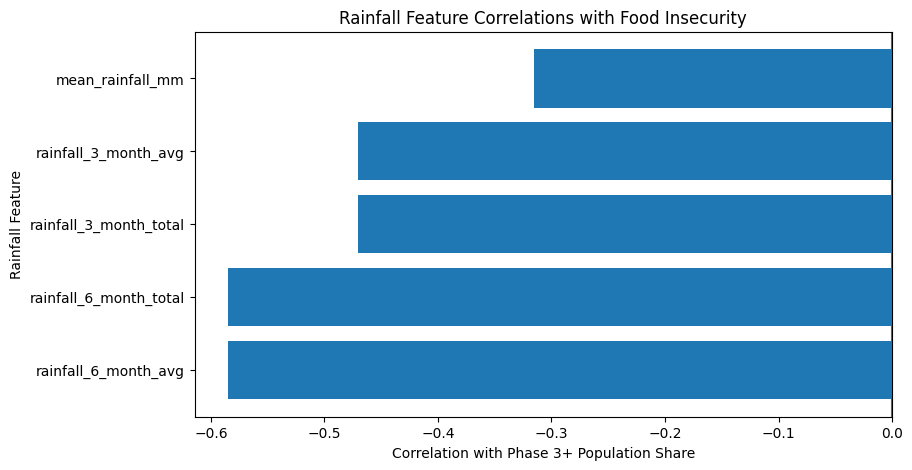

In [10]:
rainfall_corr_only = rainfall_correlation.drop("phase_3_plus_percentage")

plt.figure(figsize=(9, 5))
plt.barh(rainfall_corr_only.index, rainfall_corr_only.values)

plt.xlabel("Correlation with Phase 3+ Population Share")
plt.ylabel("Rainfall Feature")
plt.title("Rainfall Feature Correlations with Food Insecurity")
plt.axvline(0)
plt.show()

## Question 4: Which Counties Had the Highest Average Phase 3+ Population Share?

This section identifies counties where a larger share of the population was repeatedly classified in IPC Phase 3 or worse.

This helps identify priority counties for food security monitoring and early warning planning.

In [11]:
county_risk = (
    df.groupby("county")
    .agg(
        avg_phase_3_plus_percentage=("phase_3_plus_percentage", "mean"),
        avg_6_month_rainfall=("rainfall_6_month_total", "mean"),
        phase4_count=("max_ipc_phase", lambda x: (x >= 4).sum())
    )
    .reset_index()
    .sort_values("avg_phase_3_plus_percentage", ascending=False)
)

county_risk.head(10)

,county,avg_phase_3_plus_percentage,avg_6_month_rainfall,phase4_count
20,Turkana,0.302979,84.362938,13
11,Mandera,0.292857,97.547279,13
12,Marsabit,0.291979,111.172318,11
21,Wajir,0.250000,133.414189,12
2,Garissa,0.242857,110.107078,9
3,Isiolo,0.232143,72.913286,9
18,Tana River,0.232143,115.544507,8
16,Samburu,0.221429,136.668407,9
0,Baringo,0.164286,234.559108,6
7,Kwale,0.114286,263.621854,2


### Interpretation

The county risk summary shows that Turkana, Mandera, Marsabit, Wajir, Garissa, Isiolo, Tana River, and Samburu had the highest average shares of people in IPC Phase 3 or worse.

Turkana had the highest average Phase 3+ population share at about 30.3%, followed closely by Mandera and Marsabit. Turkana and Mandera also reached IPC Phase 4 or worse in 13 analysis periods, showing that these counties experienced repeated severe food insecurity conditions.

The results suggest that food insecurity risk is concentrated in a group of northern and arid/semi-arid counties. Many of these counties also had relatively low average 6-month rainfall totals, supporting the earlier finding that rainfall deficits are associated with higher food insecurity severity.

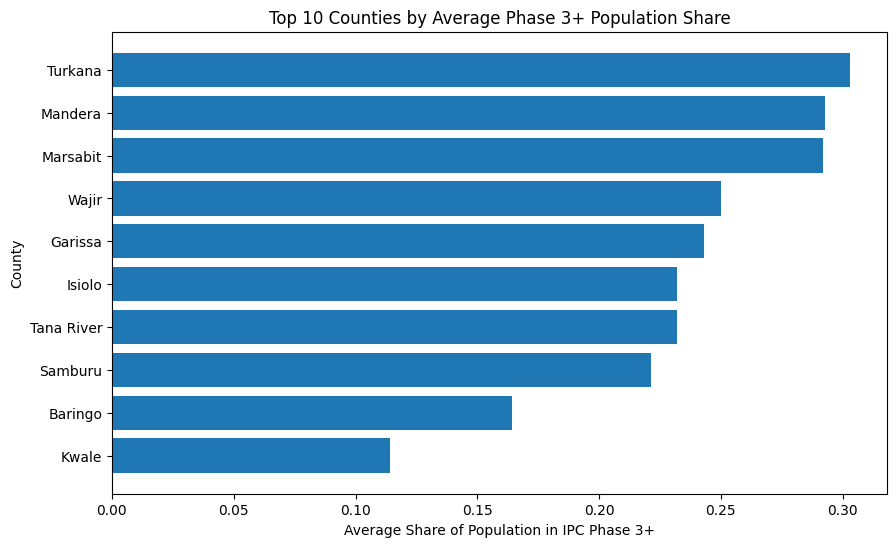

In [14]:
top_county_risk = county_risk.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_county_risk["county"],
    top_county_risk["avg_phase_3_plus_percentage"]
)

plt.xlabel("Average Share of Population in IPC Phase 3+")
plt.ylabel("County")
plt.title("Top 10 Counties by Average Phase 3+ Population Share")
plt.gca().invert_yaxis()
plt.show()

### Chart Interpretation

The chart shows the top 10 counties by average share of population in IPC Phase 3 or worse.

Turkana, Mandera, and Marsabit had the highest average Phase 3+ population shares, followed by Wajir, Garissa, Isiolo, Tana River, and Samburu.

This confirms that food insecurity risk is concentrated in a smaller group of counties, especially northern and arid/semi-arid counties. These counties should be prioritized for early warning monitoring and deeper analysis.

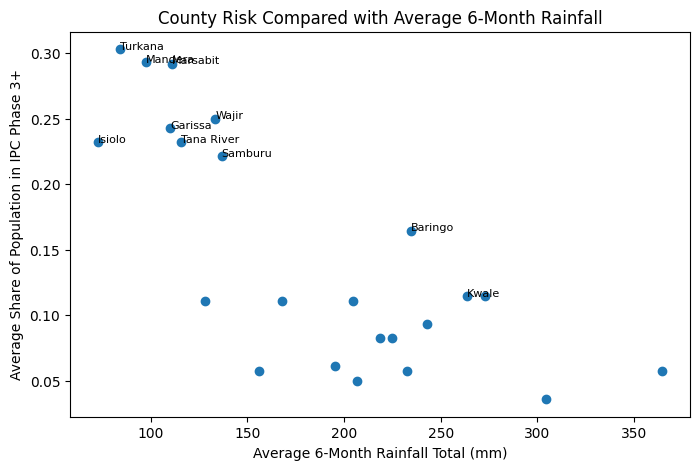

In [15]:
plt.figure(figsize=(8, 5))
plt.scatter(
    county_risk["avg_6_month_rainfall"],
    county_risk["avg_phase_3_plus_percentage"]
)

for _, row in county_risk.head(10).iterrows():
    plt.text(
        row["avg_6_month_rainfall"],
        row["avg_phase_3_plus_percentage"],
        row["county"],
        fontsize=8
    )

plt.xlabel("Average 6-Month Rainfall Total (mm)")
plt.ylabel("Average Share of Population in IPC Phase 3+")
plt.title("County Risk Compared with Average 6-Month Rainfall")
plt.show()

### Interpretation

The county-level scatter plot shows that many of the highest-risk counties are located in the low-rainfall and high-food-insecurity area of the chart.

Turkana, Mandera, Marsabit, Wajir, Garissa, Isiolo, Tana River, and Samburu have relatively high average Phase 3+ population shares and generally lower average 6-month rainfall totals.

This supports the earlier finding that rainfall deficits are associated with higher food insecurity risk. It also helps identify priority counties for early warning monitoring, especially counties that combine low rainfall exposure with repeated food insecurity severity.

In [16]:
def classify_risk(value):
    if value >= 0.20:
        return "High Risk"
    elif value >= 0.10:
        return "Medium Risk"
    else:
        return "Lower Risk"

county_risk["risk_category"] = county_risk["avg_phase_3_plus_percentage"].apply(classify_risk)

county_risk.sort_values("avg_phase_3_plus_percentage", ascending=False)

,county,avg_phase_3_plus_percentage,avg_6_month_rainfall,phase4_count,risk_category
20,Turkana,0.302979,84.362938,13,High Risk
11,Mandera,0.292857,97.547279,13,High Risk
12,Marsabit,0.291979,111.172318,11,High Risk
21,Wajir,0.250000,133.414189,12,High Risk
2,Garissa,0.242857,110.107078,9,High Risk
3,Isiolo,0.232143,72.913286,9,High Risk
18,Tana River,0.232143,115.544507,8,High Risk
16,Samburu,0.221429,136.668407,9,High Risk
0,Baringo,0.164286,234.559108,6,Medium Risk
7,Kwale,0.114286,263.621854,2,Medium Risk


### Risk Category Interpretation

The risk classification groups counties based on their average Phase 3+ population share.

Counties with an average Phase 3+ share of 20% or more were classified as High Risk. This includes Turkana, Mandera, Marsabit, Wajir, Garissa, Isiolo, Tana River, and Samburu.

Counties between 10% and 20% were classified as Medium Risk, while counties below 10% were classified as Lower Risk.

This classification helps translate the analysis into a practical early warning view by identifying counties that may need closer monitoring and priority planning.

In [17]:
county_risk["risk_category"].value_counts()

risk_category
Lower Risk     9
High Risk      8
Medium Risk    6
Name: count, dtype: int64

## Risk Category Distribution

This section summarizes how many counties fall into each risk category.

The risk category distribution helps show how food insecurity risk is spread across the 23 target counties.

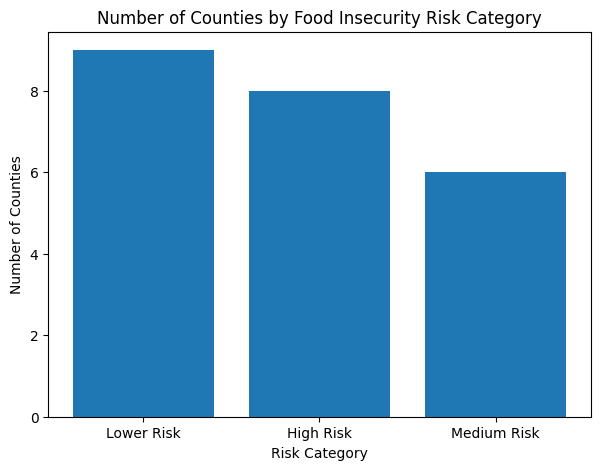

In [18]:
risk_counts = county_risk["risk_category"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(risk_counts.index, risk_counts.values)

plt.xlabel("Risk Category")
plt.ylabel("Number of Counties")
plt.title("Number of Counties by Food Insecurity Risk Category")
plt.show()

### Risk Category Distribution Interpretation

The risk category chart shows that 8 of the 23 target counties were classified as High Risk, 6 as Medium Risk, and 9 as Lower Risk.

This means that a significant share of the target counties experienced repeated food insecurity pressure. The High Risk group should be prioritized for early warning monitoring, especially when rainfall conditions begin to decline.

## Save County Risk Summary

The county risk summary ranks counties by their average Phase 3+ population share, average 6-month rainfall, Phase 4 frequency, and assigned risk category.

This output can be used in the project dashboard, README summary, and final portfolio visuals.

In [19]:
COUNTY_RISK_PATH = Path("../02_data/processed/county_risk_summary.csv")

county_risk.to_csv(COUNTY_RISK_PATH, index=False)

print(f"Saved county risk summary to: {COUNTY_RISK_PATH}")

Saved county risk summary to: ..\02_data\processed\county_risk_summary.csv


In [20]:
COUNTY_RISK_PATH.exists()

True

## Final Analysis Summary

This analysis explored the relationship between CHIRPS rainfall features and IPC food insecurity severity across 23 target counties in Kenya.

### Key Findings

1. **Rainfall and food insecurity are negatively related**

The analysis found that lower rainfall is associated with higher food insecurity severity. Counties with lower 6-month rainfall totals generally had higher shares of population in IPC Phase 3 or worse.

2. **The 6-month rainfall feature was the strongest rainfall signal**

The correlation between `rainfall_6_month_total` and `phase_3_plus_percentage` was approximately `-0.585`, showing a moderate negative relationship.

This suggests that seasonal rainfall conditions are more useful for food insecurity analysis than rainfall from only one month.

3. **High-risk counties were concentrated in northern and arid/semi-arid areas**

The counties with the highest average Phase 3+ population shares included:

- Turkana
- Mandera
- Marsabit
- Wajir
- Garissa
- Isiolo
- Tana River
- Samburu

These counties also showed repeated severe IPC outcomes, including multiple Phase 4 periods.

4. **County risk categories were created**

Counties were classified into three risk categories:

- High Risk
- Medium Risk
- Lower Risk

The final classification found:

- 8 High Risk counties
- 6 Medium Risk counties
- 9 Lower Risk counties

### Project Value

This stage shows how raw humanitarian and climate data can be transformed into practical early warning insights.

The project now has a modeling-ready dataset, rainfall features, and county-level risk summaries that can support dashboard development, further analysis, and future predictive modeling.

In [21]:
final_files = [
    "../02_data/processed/ipc_max_phase_per_county.csv",
    "../02_data/processed/county_rainfall.csv",
    "../02_data/processed/county_rainfall_features.csv",
    "../02_data/processed/ipc_rainfall_modeling_dataset.csv",
    "../02_data/processed/county_risk_summary.csv",
    "../02_data/processed/kenya_target_counties.geojson"
]

for file in final_files:
    path = Path(file)
    print(path.name, "exists:", path.exists())

ipc_max_phase_per_county.csv exists: True
county_rainfall.csv exists: True
county_rainfall_features.csv exists: True
ipc_rainfall_modeling_dataset.csv exists: True
county_risk_summary.csv exists: True
kenya_target_counties.geojson exists: True
